<a href="https://colab.research.google.com/github/shake345/Python100knock/blob/main/4%E7%AB%A0_%E5%8A%A0%E5%B7%A5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [47]:
# 下記セルを実行すると、authorization codeの入力を求められます。
# 出力されたリンク先をクリックし、Googleアカウントにログインし、
# authorization codeをコピーし、貼り付けをおこなってください。
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [48]:
import os
project = '100knock-process-visualization'
chapter = 4
os.chdir(f'/content/drive/MyDrive/{project}/chapter-{chapter}/')

# ４章 言語データの加工・可視化を行う１０本ノック

## ノック５１：テキストファイルを読み込もう

In [49]:
ls data/

hashire_merosu.txt  stop_words.txt


In [50]:
with open('data/hashire_merosu.txt',mode='r',encoding='shift-jis') as f:
  content = f.read()
print(content)

走れメロス
太宰治

-------------------------------------------------------
【テキスト中に現れる記号について】

《》：ルビ
（例）邪智暴虐《じゃちぼうぎゃく》

｜：ルビの付く文字列の始まりを特定する記号
（例）疲労｜困憊《こんぱい》

［＃］：入力者注　主に外字の説明や、傍点の位置の指定
（例）［＃地から１字上げ］
-------------------------------------------------------

　メロスは激怒した。必ず、かの邪智暴虐《じゃちぼうぎゃく》の王を除かなければならぬと決意した。メロスには政治がわからぬ。メロスは、村の牧人である。笛を吹き、羊と遊んで暮して来た。けれども邪悪に対しては、人一倍に敏感であった。きょう未明メロスは村を出発し、野を越え山越え、十里はなれた此《こ》のシラクスの市にやって来た。メロスには父も、母も無い。女房も無い。十六の、内気な妹と二人暮しだ。この妹は、村の或る律気な一牧人を、近々、花婿《はなむこ》として迎える事になっていた。結婚式も間近かなのである。メロスは、それゆえ、花嫁の衣裳やら祝宴の御馳走やらを買いに、はるばる市にやって来たのだ。先ず、その品々を買い集め、それから都の大路をぶらぶら歩いた。メロスには竹馬の友があった。セリヌンティウスである。今は此のシラクスの市で、石工をしている。その友を、これから訪ねてみるつもりなのだ。久しく逢わなかったのだから、訪ねて行くのが楽しみである。歩いているうちにメロスは、まちの様子を怪しく思った。ひっそりしている。もう既に日も落ちて、まちの暗いのは当りまえだが、けれども、なんだか、夜のせいばかりでは無く、市全体が、やけに寂しい。のんきなメロスも、だんだん不安になって来た。路で逢った若い衆をつかまえて、何かあったのか、二年まえに此の市に来たときは、夜でも皆が歌をうたって、まちは賑やかであった筈《はず》だが、と質問した。若い衆は、首を振って答えなかった。しばらく歩いて老爺《ろうや》に逢い、こんどはもっと、語勢を強くして質問した。老爺は答えなかった。メロスは両手で老爺のからだをゆすぶって質問を重ねた。老爺は、あたりをはばかる低声で、わずか答えた。
「王様は、人を殺します。」
「なぜ殺すのだ。」
「悪心を抱いてい

## ノック５２：本文を抽出して１つに纏めよう

In [51]:
content = ' '.join(content.split())
content

'走れメロス 太宰治 ------------------------------------------------------- 【テキスト中に現れる記号について】 《》：ルビ （例）邪智暴虐《じゃちぼうぎゃく》 ｜：ルビの付く文字列の始まりを特定する記号 （例）疲労｜困憊《こんぱい》 ［＃］：入力者注 主に外字の説明や、傍点の位置の指定 （例）［＃地から１字上げ］ ------------------------------------------------------- メロスは激怒した。必ず、かの邪智暴虐《じゃちぼうぎゃく》の王を除かなければならぬと決意した。メロスには政治がわからぬ。メロスは、村の牧人である。笛を吹き、羊と遊んで暮して来た。けれども邪悪に対しては、人一倍に敏感であった。きょう未明メロスは村を出発し、野を越え山越え、十里はなれた此《こ》のシラクスの市にやって来た。メロスには父も、母も無い。女房も無い。十六の、内気な妹と二人暮しだ。この妹は、村の或る律気な一牧人を、近々、花婿《はなむこ》として迎える事になっていた。結婚式も間近かなのである。メロスは、それゆえ、花嫁の衣裳やら祝宴の御馳走やらを買いに、はるばる市にやって来たのだ。先ず、その品々を買い集め、それから都の大路をぶらぶら歩いた。メロスには竹馬の友があった。セリヌンティウスである。今は此のシラクスの市で、石工をしている。その友を、これから訪ねてみるつもりなのだ。久しく逢わなかったのだから、訪ねて行くのが楽しみである。歩いているうちにメロスは、まちの様子を怪しく思った。ひっそりしている。もう既に日も落ちて、まちの暗いのは当りまえだが、けれども、なんだか、夜のせいばかりでは無く、市全体が、やけに寂しい。のんきなメロスも、だんだん不安になって来た。路で逢った若い衆をつかまえて、何かあったのか、二年まえに此の市に来たときは、夜でも皆が歌をうたって、まちは賑やかであった筈《はず》だが、と質問した。若い衆は、首を振って答えなかった。しばらく歩いて老爺《ろうや》に逢い、こんどはもっと、語勢を強くして質問した。老爺は答えなかった。メロスは両手で老爺のからだをゆすぶって質問を重ねた。老爺は、あたりをはばかる低声で、わずか答えた。 「王様は、人を殺します。」 「なぜ殺すのだ。」 「悪心を抱いている、という

In [52]:
import unicodedata
content = unicodedata.normalize('NFKC',content)
content

'走れメロス 太宰治 ------------------------------------------------------- 【テキスト中に現れる記号について】 《》:ルビ (例)邪智暴虐《じゃちぼうぎゃく》 |:ルビの付く文字列の始まりを特定する記号 (例)疲労|困憊《こんぱい》 [#]:入力者注 主に外字の説明や、傍点の位置の指定 (例)[#地から1字上げ] ------------------------------------------------------- メロスは激怒した。必ず、かの邪智暴虐《じゃちぼうぎゃく》の王を除かなければならぬと決意した。メロスには政治がわからぬ。メロスは、村の牧人である。笛を吹き、羊と遊んで暮して来た。けれども邪悪に対しては、人一倍に敏感であった。きょう未明メロスは村を出発し、野を越え山越え、十里はなれた此《こ》のシラクスの市にやって来た。メロスには父も、母も無い。女房も無い。十六の、内気な妹と二人暮しだ。この妹は、村の或る律気な一牧人を、近々、花婿《はなむこ》として迎える事になっていた。結婚式も間近かなのである。メロスは、それゆえ、花嫁の衣裳やら祝宴の御馳走やらを買いに、はるばる市にやって来たのだ。先ず、その品々を買い集め、それから都の大路をぶらぶら歩いた。メロスには竹馬の友があった。セリヌンティウスである。今は此のシラクスの市で、石工をしている。その友を、これから訪ねてみるつもりなのだ。久しく逢わなかったのだから、訪ねて行くのが楽しみである。歩いているうちにメロスは、まちの様子を怪しく思った。ひっそりしている。もう既に日も落ちて、まちの暗いのは当りまえだが、けれども、なんだか、夜のせいばかりでは無く、市全体が、やけに寂しい。のんきなメロスも、だんだん不安になって来た。路で逢った若い衆をつかまえて、何かあったのか、二年まえに此の市に来たときは、夜でも皆が歌をうたって、まちは賑やかであった筈《はず》だが、と質問した。若い衆は、首を振って答えなかった。しばらく歩いて老爺《ろうや》に逢い、こんどはもっと、語勢を強くして質問した。老爺は答えなかった。メロスは両手で老爺のからだをゆすぶって質問を重ねた。老爺は、あたりをはばかる低声で、わずか答えた。 「王様は、人を殺します。」 「なぜ殺すのだ。」 「悪心を抱いている、という

In [53]:
import re
pattern = re.compile(r'^.+(#地から1字上げ].+#地から1字上げ]).+$')
body = re.match(pattern,content).group(1)
print(body)

#地から1字上げ] ------------------------------------------------------- メロスは激怒した。必ず、かの邪智暴虐《じゃちぼうぎゃく》の王を除かなければならぬと決意した。メロスには政治がわからぬ。メロスは、村の牧人である。笛を吹き、羊と遊んで暮して来た。けれども邪悪に対しては、人一倍に敏感であった。きょう未明メロスは村を出発し、野を越え山越え、十里はなれた此《こ》のシラクスの市にやって来た。メロスには父も、母も無い。女房も無い。十六の、内気な妹と二人暮しだ。この妹は、村の或る律気な一牧人を、近々、花婿《はなむこ》として迎える事になっていた。結婚式も間近かなのである。メロスは、それゆえ、花嫁の衣裳やら祝宴の御馳走やらを買いに、はるばる市にやって来たのだ。先ず、その品々を買い集め、それから都の大路をぶらぶら歩いた。メロスには竹馬の友があった。セリヌンティウスである。今は此のシラクスの市で、石工をしている。その友を、これから訪ねてみるつもりなのだ。久しく逢わなかったのだから、訪ねて行くのが楽しみである。歩いているうちにメロスは、まちの様子を怪しく思った。ひっそりしている。もう既に日も落ちて、まちの暗いのは当りまえだが、けれども、なんだか、夜のせいばかりでは無く、市全体が、やけに寂しい。のんきなメロスも、だんだん不安になって来た。路で逢った若い衆をつかまえて、何かあったのか、二年まえに此の市に来たときは、夜でも皆が歌をうたって、まちは賑やかであった筈《はず》だが、と質問した。若い衆は、首を振って答えなかった。しばらく歩いて老爺《ろうや》に逢い、こんどはもっと、語勢を強くして質問した。老爺は答えなかった。メロスは両手で老爺のからだをゆすぶって質問を重ねた。老爺は、あたりをはばかる低声で、わずか答えた。 「王様は、人を殺します。」 「なぜ殺すのだ。」 「悪心を抱いている、というのですが、誰もそんな、悪心を持っては居りませぬ。」 「たくさんの人を殺したのか。」 「はい、はじめは王様の妹婿さまを。それから、御自身のお世嗣《よつぎ》を。それから、妹さまを。それから、妹さまの御子さまを。それから、皇后さまを。それから、賢臣のアレキス様を。」 「おどろいた。国王は乱心か。」 「いいえ、乱心ではございませぬ。人を、信ずる事が出来ぬ、とい

In [54]:
body = body.replace('#地から1字上げ] ------------------------------------------------------- ','')
body = body.replace('[#地から1字上げ]','')
body

'メロスは激怒した。必ず、かの邪智暴虐《じゃちぼうぎゃく》の王を除かなければならぬと決意した。メロスには政治がわからぬ。メロスは、村の牧人である。笛を吹き、羊と遊んで暮して来た。けれども邪悪に対しては、人一倍に敏感であった。きょう未明メロスは村を出発し、野を越え山越え、十里はなれた此《こ》のシラクスの市にやって来た。メロスには父も、母も無い。女房も無い。十六の、内気な妹と二人暮しだ。この妹は、村の或る律気な一牧人を、近々、花婿《はなむこ》として迎える事になっていた。結婚式も間近かなのである。メロスは、それゆえ、花嫁の衣裳やら祝宴の御馳走やらを買いに、はるばる市にやって来たのだ。先ず、その品々を買い集め、それから都の大路をぶらぶら歩いた。メロスには竹馬の友があった。セリヌンティウスである。今は此のシラクスの市で、石工をしている。その友を、これから訪ねてみるつもりなのだ。久しく逢わなかったのだから、訪ねて行くのが楽しみである。歩いているうちにメロスは、まちの様子を怪しく思った。ひっそりしている。もう既に日も落ちて、まちの暗いのは当りまえだが、けれども、なんだか、夜のせいばかりでは無く、市全体が、やけに寂しい。のんきなメロスも、だんだん不安になって来た。路で逢った若い衆をつかまえて、何かあったのか、二年まえに此の市に来たときは、夜でも皆が歌をうたって、まちは賑やかであった筈《はず》だが、と質問した。若い衆は、首を振って答えなかった。しばらく歩いて老爺《ろうや》に逢い、こんどはもっと、語勢を強くして質問した。老爺は答えなかった。メロスは両手で老爺のからだをゆすぶって質問を重ねた。老爺は、あたりをはばかる低声で、わずか答えた。 「王様は、人を殺します。」 「なぜ殺すのだ。」 「悪心を抱いている、というのですが、誰もそんな、悪心を持っては居りませぬ。」 「たくさんの人を殺したのか。」 「はい、はじめは王様の妹婿さまを。それから、御自身のお世嗣《よつぎ》を。それから、妹さまを。それから、妹さまの御子さまを。それから、皇后さまを。それから、賢臣のアレキス様を。」 「おどろいた。国王は乱心か。」 「いいえ、乱心ではございませぬ。人を、信ずる事が出来ぬ、というのです。このごろは、臣下の心をも、お疑いになり、少しく派手な暮しをしている者には、人質ひとりずつ差し出すことを命じて居ります。御

## ノック５３：本文以外の項目を取り出そう

In [55]:
with open('data/hashire_merosu.txt',mode='r',encoding='shift-jis') as f:
  title = f.readline()
  author = f.readline()
print(title)
print(author)

走れメロス

太宰治



In [56]:
title = title.replace('\n','')
print(title)
author = author.replace('\n','')
print(author)

走れメロス
太宰治


In [57]:
with open('data/hashire_merosu.txt',mode='r',encoding='shift-jis') as f:
  content = f.readlines()
content

['走れメロス\n',
 '太宰治\n',
 '\n',
 '-------------------------------------------------------\n',
 '【テキスト中に現れる記号について】\n',
 '\n',
 '《》：ルビ\n',
 '（例）邪智暴虐《じゃちぼうぎゃく》\n',
 '\n',
 '｜：ルビの付く文字列の始まりを特定する記号\n',
 '（例）疲労｜困憊《こんぱい》\n',
 '\n',
 '［＃］：入力者注\u3000主に外字の説明や、傍点の位置の指定\n',
 '（例）［＃地から１字上げ］\n',
 '-------------------------------------------------------\n',
 '\n',
 '\u3000メロスは激怒した。必ず、かの邪智暴虐《じゃちぼうぎゃく》の王を除かなければならぬと決意した。メロスには政治がわからぬ。メロスは、村の牧人である。笛を吹き、羊と遊んで暮して来た。けれども邪悪に対しては、人一倍に敏感であった。きょう未明メロスは村を出発し、野を越え山越え、十里はなれた此《こ》のシラクスの市にやって来た。メロスには父も、母も無い。女房も無い。十六の、内気な妹と二人暮しだ。この妹は、村の或る律気な一牧人を、近々、花婿《はなむこ》として迎える事になっていた。結婚式も間近かなのである。メロスは、それゆえ、花嫁の衣裳やら祝宴の御馳走やらを買いに、はるばる市にやって来たのだ。先ず、その品々を買い集め、それから都の大路をぶらぶら歩いた。メロスには竹馬の友があった。セリヌンティウスである。今は此のシラクスの市で、石工をしている。その友を、これから訪ねてみるつもりなのだ。久しく逢わなかったのだから、訪ねて行くのが楽しみである。歩いているうちにメロスは、まちの様子を怪しく思った。ひっそりしている。もう既に日も落ちて、まちの暗いのは当りまえだが、けれども、なんだか、夜のせいばかりでは無く、市全体が、やけに寂しい。のんきなメロスも、だんだん不安になって来た。路で逢った若い衆をつかまえて、何かあったのか、二年まえに此の市に来たときは、夜でも皆が歌をうたって、まちは賑やかであった筈《はず》だが、と質問した。若い衆は、首を振って答えなかった。しばらく歩いて老爺《ろうや》に逢い、こんどは

In [58]:
import pandas as pd
df = pd.DataFrame(content,columns=['text'])
df['text'] = df['text'].str.replace('\n','')
df

,text
0,走れメロス
1,太宰治
2,
3,----------------------------------------------...
4,【テキスト中に現れる記号について】
...,...
100,校正：高橋美奈子
101,2000年12月4日公開
102,2011年1月17日修正
103,青空文庫作成ファイル：


In [59]:
date = df[(df['text'].str.contains('日公開'))|(df['text'].str.contains('日修正'))].copy()
print(date)

date['text'] = date['text'].str.replace('公開','')
date['text'] = date['text'].str.replace('修正','')
print(date)

date['text'] = date['text'].str.replace('年','/')
date['text'] = date['text'].str.replace('月','/')
date['text'] = date['text'].str.replace('日','')
print(date)

date['text'] = pd.to_datetime(date['text'])
print(date)
date.dtypes

             text
101  2000年12月4日公開
102  2011年1月17日修正
           text
101  2000年12月4日
102  2011年1月17日
          text
101  2000/12/4
102  2011/1/17
          text
101 2000-12-04
102 2011-01-17


,0
text,datetime64[ns]


In [60]:
release_date = date.iat[0,0]
update_date = date.iat[1,0]
print(release_date)
print(update_date)
date = update_date - release_date
print(date)


2000-12-04 00:00:00
2011-01-17 00:00:00
3696 days 00:00:00


In [61]:
booklist = pd.DataFrame([[title,author,release_date,update_date,body]],columns=['title','author','release_date','update_date','body'])
booklist

,title,author,release_date,update_date,body
0,走れメロス,太宰治,2000-12-04,2011-01-17,メロスは激怒した。必ず、かの邪智暴虐《じゃちぼうぎゃく》の王を除かなければならぬと決意した。...


## ノック５４：形態素解析で単語に分割しよう

In [62]:
%%bash

apt update -yq
apt install -yq \
  mecab \
  mecab-ipadic-utf8 \
  libmecab-dev

pip install --upgrade pip setuptools wheel
# mecab-python3==0.996.5 のインストールが失敗したため、Colabで実績のあるバージョンを試します
pip install -q mecab-python3==1.0.5

if [ ! -f "/usr/local/etc/mecabrc" ]; then
  ln -s /etc/mecabrc /usr/local/etc/mecabrc
fi

Hit:1 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:2 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:3 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Hit:4 https://cli.github.com/packages stable InRelease
Get:5 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Hit:6 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:7 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:8 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 Packages [4,107 kB]
Get:9 http://archive.ubuntu.com/ubuntu jammy-updates/universe amd64 Packages [1,613 kB]
Hit:10 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Get:11 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Fetched 6,108 kB in 5s (1,341 kB/s)
Reading package lists...
Building dependency tree...
Reading state information...
97 packages can be upgraded. Run 'apt list --upgradable' to see them.
Reading pac



W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)




In [63]:
pip list | grep mecab

mecab-python3                            1.0.5


In [64]:
import MeCab
tagger = MeCab.Tagger()
body = booklist.iloc[0,4]
parsed = tagger.parse(body).split('\n')
parsed[:4]

['メロス\t名詞,一般,*,*,*,*,*',
 'は\t助詞,係助詞,*,*,*,*,は,ハ,ワ',
 '激怒\t名詞,サ変接続,*,*,*,*,激怒,ゲキド,ゲキド',
 'し\t動詞,自立,*,*,サ変・スル,連用形,する,シ,シ']

In [65]:
parsed[-4:]

['た\t助動詞,*,*,*,特殊・タ,基本形,た,タ,タ', '。\t記号,句点,*,*,*,*,。,。,。', 'EOS', '']

In [66]:
parsed = parsed[:-2]
parsed[-4:]

['赤面\t名詞,サ変接続,*,*,*,*,赤面,セキメン,セキメン',
 'し\t動詞,自立,*,*,サ変・スル,連用形,する,シ,シ',
 'た\t助動詞,*,*,*,特殊・タ,基本形,た,タ,タ',
 '。\t記号,句点,*,*,*,*,。,。,。']

## ノック５５：分割した単語をデータフレームで保持しよう

In [67]:
*values, = map(lambda s: re.split(r'\t|,',s),parsed)
values[:4]

[['メロス', '名詞', '一般', '*', '*', '*', '*', '*'],
 ['は', '助詞', '係助詞', '*', '*', '*', '*', 'は', 'ハ', 'ワ'],
 ['激怒', '名詞', 'サ変接続', '*', '*', '*', '*', '激怒', 'ゲキド', 'ゲキド'],
 ['し', '動詞', '自立', '*', '*', 'サ変・スル', '連用形', 'する', 'シ', 'シ']]

In [68]:
import pandas as pd
columns = ['表層形','品詞','品詞細分類1','品詞細分類2','品詞細分類3','活用型','活用形','原型','読み','発音']
mecab_df = pd.DataFrame(data=values,columns=columns)
print(len(mecab_df))
mecab_df.head(4)

6712


,表層形,品詞,品詞細分類1,品詞細分類2,品詞細分類3,活用型,活用形,原型,読み,発音
0,メロス,名詞,一般,*,*,*,*,*,None,None
1,は,助詞,係助詞,*,*,*,*,は,ハ,ワ
2,激怒,名詞,サ変接続,*,*,*,*,激怒,ゲキド,ゲキド
3,し,動詞,自立,*,*,サ変・スル,連用形,する,シ,シ


## ノック５６：名詞と動詞を取り出そう

In [69]:
print(mecab_df.groupby(['原型','品詞']).size().sort_values(ascending=False))

原型   品詞 
、    記号     555
。    記号     458
は    助詞     268
て    助詞     237
の    助詞     225
           ... 
頑強   名詞       1
響き   名詞       1
鞭打つ  動詞       1
面白い  形容詞      1
面前   名詞       1
Length: 1325, dtype: int64


In [70]:
noun = mecab_df.loc[mecab_df['品詞']=='名詞']
noun

,表層形,品詞,品詞細分類1,品詞細分類2,品詞細分類3,活用型,活用形,原型,読み,発音
0,メロス,名詞,一般,*,*,*,*,*,None,None
2,激怒,名詞,サ変接続,*,*,*,*,激怒,ゲキド,ゲキド
9,邪智,名詞,一般,*,*,*,*,邪智,ジャチ,ジャチ
10,暴虐,名詞,一般,*,*,*,*,暴虐,ボウギャク,ボーギャク
13,ゃちぼうぎゃく,名詞,固有名詞,組織,*,*,*,*,None,None
...,...,...,...,...,...,...,...,...,...,...
6691,皆,名詞,代名詞,一般,*,*,*,皆,ミナ,ミナ
6695,の,名詞,非自立,一般,*,*,*,の,ノ,ノ
6700,の,名詞,非自立,一般,*,*,*,の,ノ,ノ
6704,勇者,名詞,一般,*,*,*,*,勇者,ユウシャ,ユーシャ


In [71]:
verb = mecab_df.loc[(mecab_df['品詞']=='名詞')|(mecab_df['品詞']=='動詞')]
verb

,表層形,品詞,品詞細分類1,品詞細分類2,品詞細分類3,活用型,活用形,原型,読み,発音
0,メロス,名詞,一般,*,*,*,*,*,None,None
2,激怒,名詞,サ変接続,*,*,*,*,激怒,ゲキド,ゲキド
3,し,動詞,自立,*,*,サ変・スル,連用形,する,シ,シ
9,邪智,名詞,一般,*,*,*,*,邪智,ジャチ,ジャチ
10,暴虐,名詞,一般,*,*,*,*,暴虐,ボウギャク,ボーギャク
...,...,...,...,...,...,...,...,...,...,...
6695,の,名詞,非自立,一般,*,*,*,の,ノ,ノ
6700,の,名詞,非自立,一般,*,*,*,の,ノ,ノ
6704,勇者,名詞,一般,*,*,*,*,勇者,ユウシャ,ユーシャ
6708,赤面,名詞,サ変接続,*,*,*,*,赤面,セキメン,セキメン


## ノック５７：不要な単語を除外しよう

In [72]:
with open('data/stop_words.txt',mode='r') as f:
  stop_words = f.read().split()
stop_words

['する', 'いる', 'なる', 'れる', 'よう']

In [73]:
print(len(noun))
noun = noun.loc[~noun['原型'].isin(stop_words)]
print(len(noun))
display(noun.head())

print(len(verb))
verb = verb.loc[~verb['原型'].isin(stop_words)]
print(len(verb))
display(verb.head())


1686
1673


,表層形,品詞,品詞細分類1,品詞細分類2,品詞細分類3,活用型,活用形,原型,読み,発音
0,メロス,名詞,一般,*,*,*,*,*,None,None
2,激怒,名詞,サ変接続,*,*,*,*,激怒,ゲキド,ゲキド
9,邪智,名詞,一般,*,*,*,*,邪智,ジャチ,ジャチ
10,暴虐,名詞,一般,*,*,*,*,暴虐,ボウギャク,ボーギャク
13,ゃちぼうぎゃく,名詞,固有名詞,組織,*,*,*,*,None,None


2666
2448


,表層形,品詞,品詞細分類1,品詞細分類2,品詞細分類3,活用型,活用形,原型,読み,発音
0,メロス,名詞,一般,*,*,*,*,*,None,None
2,激怒,名詞,サ変接続,*,*,*,*,激怒,ゲキド,ゲキド
9,邪智,名詞,一般,*,*,*,*,邪智,ジャチ,ジャチ
10,暴虐,名詞,一般,*,*,*,*,暴虐,ボウギャク,ボーギャク
13,ゃちぼうぎゃく,名詞,固有名詞,組織,*,*,*,*,None,None


## ノック５８：単語の使用状況をグラフで可視化しよう

In [74]:
count = noun.groupby('原型').size().sort_values(ascending=False)
count.name = 'count'
count = count.reset_index().head(10)
count

,原型,count
0,*,155
1,の,78
2,私,76
3,人,30
4,おまえ,20
5,王,19
6,友,18
7,事,15
8,君,13
9,男,12


In [75]:
!pip install -q japanize-matplotlib

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


<Axes: xlabel='count', ylabel='原型'>

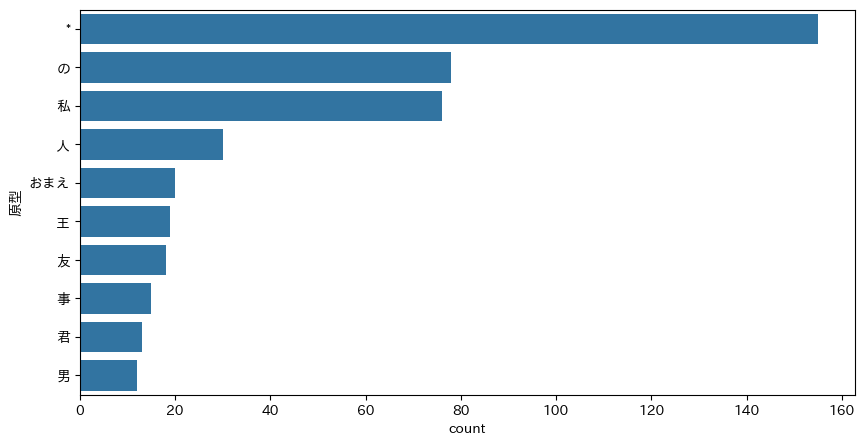

In [77]:
import matplotlib.pyplot as plt
import seaborn as sns
import japanize_matplotlib
plt.figure(figsize=(10,5))
sns.barplot(x=count['count'],y=count['原型'])

## ノック５９：単語の傾向をWordCloudで可視化してみよう

## ノック６０：n-gramを作ってみよう